In [ ]:
import numpy as np; import datasets; ds = datasets.load_dataset("scikit-learn/Fish"); ds

DatasetDict({
    train: Dataset({
        features: ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width'],
        num_rows: 159
    })
})

In [7]:
import pandas as pd; df = ds['train'].to_pandas()
from sklearn.preprocessing import StandardScaler; from sklearn.model_selection import train_test_split
df.drop('Species', axis=1, inplace=True); y = df.pop('Weight'); X = df; df.info()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=23)
scaler = StandardScaler(); X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test);

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Length1  159 non-null    float64
 1   Length2  159 non-null    float64
 2   Length3  159 non-null    float64
 3   Height   159 non-null    float64
 4   Width    159 non-null    float64
dtypes: float64(5)
memory usage: 6.3 KB


In [8]:
from sklearn.linear_model import LinearRegression; from sklearn.metrics import r2_score
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train); y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred); r2_test = r2_score(y_test, y_test_pred)

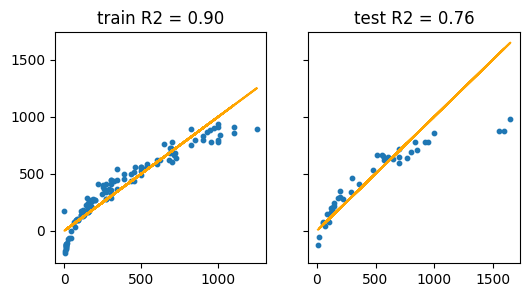

In [9]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = 'all')
ax = axs[0]; ax.set_title(f'train R2 = {r2_train:.2f}')
ax.scatter(y_train, y_train_pred, s=10); ax.plot(y_train, y_train, color='orange')
ax = axs[1]; ax.set_title(f'test R2 = {r2_test:.2f}')
ax.scatter(y_test, y_test_pred, s=10); ax.plot(y_test, y_test, color='orange');


In [10]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(3); X_train = poly.fit_transform(X_train); X_test = poly.transform(X_test)
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train); y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred); r2_test = r2_score(y_test, y_test_pred)

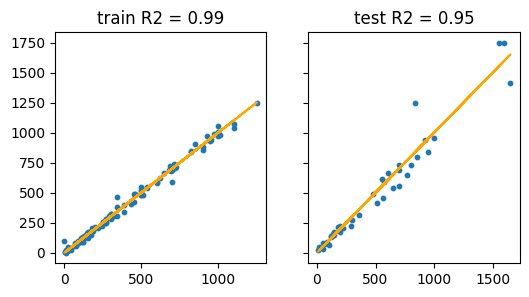

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = 'all')
ax = axs[0]; ax.set_title(f'train R2 = {r2_train:.2f}')
ax.scatter(y_train, y_train_pred, s=10); ax.plot(y_train, y_train, color='orange')
ax = axs[1]; ax.set_title(f'test R2 = {r2_test:.2f}')
ax.scatter(y_test, y_test_pred, s=10); ax.plot(y_test, y_test, color='orange');